In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
columns = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class"
]

df = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None,
    names=columns
)

In [ ]:
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
df.shape
print("\n")
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [ ]:
df.isnull().sum()

,0
Variance,0
Skewness,0
Curtosis,0
Entropy,0
Class,0


In [ ]:
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


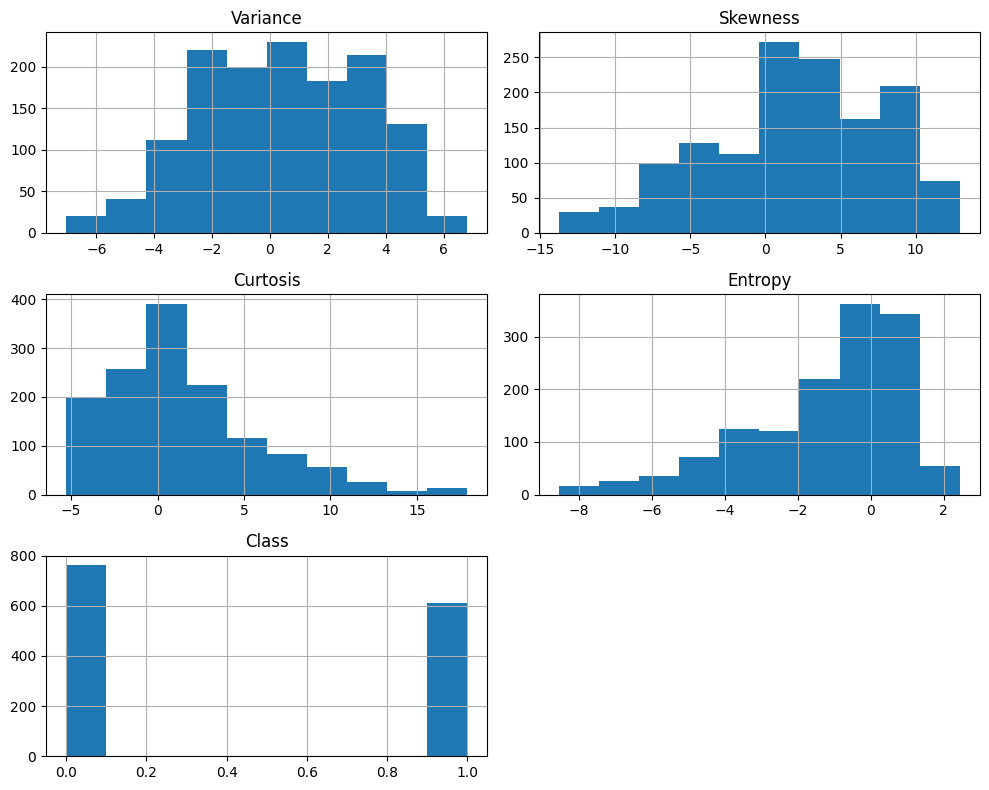

In [ ]:
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

1)Variance has a reasonably balanced distribution with most observations concentrated around the central region. There are only a few observations at the extreme ends, indicating that extreme values are limited. This feature is well distributed and is expected to contribute effectively during model training...
2)The Skewness feature exhibits a wide range of values, indicating high variability among banknotes. The distribution is not perfectly symmetric and contains more observations on the positive side, suggesting a slight skew in the data...
3)Curtosis is positively skewed, meaning that most observations are concentrated near lower values while a few observations extend towards much larger values. This suggests the presence of extreme values that may influence the learning process...
4)Entropy is concentrated around values close to zero with only a few observations at lower values. The feature shows moderate negative skewness but does not exhibit excessive dispersion.5)The target classes are relatively balanced, indicating that neither class dominates the dataset. This is beneficial because the perceptron will receive a similar number of examples from both classes during training.

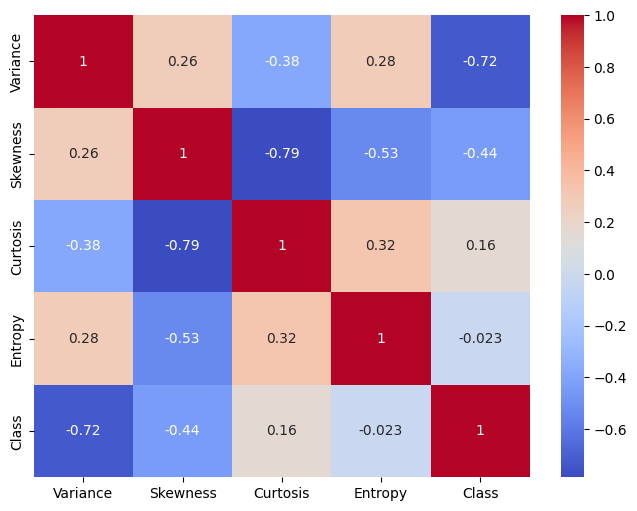

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

The correlation heatmap reveals that Variance has the strongest relationship with the target class, indicating that it is an important feature for classification. Skewness and Kurtosis exhibit a strong negative correlation, meaning they generally vary in opposite directions. Entropy shows a weak linear relationship with the target when considered individually.

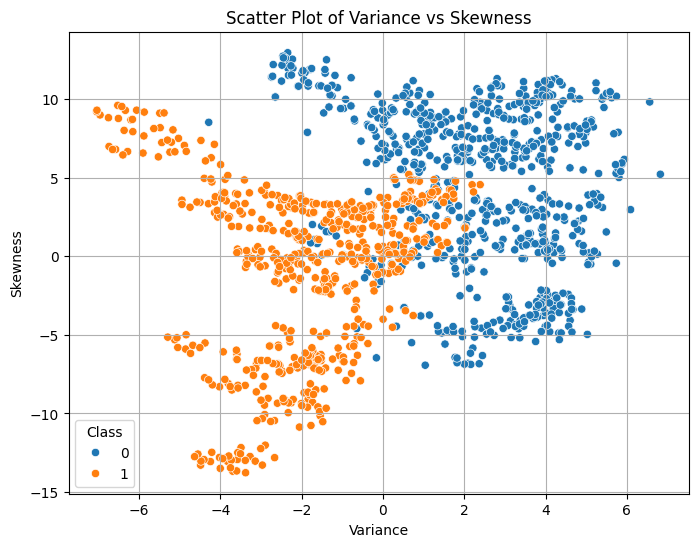

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Variance",
    y="Skewness",
    hue="Class"
)

plt.title("Scatter Plot of Variance vs Skewness")

plt.xlabel("Variance")

plt.ylabel("Skewness")

plt.legend(title="Class")

plt.grid(True)

plt.show()

The scatter plot shows that the two classes occupy distinct regions in the feature space with only a small overlap. Most authentic banknotes are concentrated at higher variance values, while forged banknotes are concentrated at lower variance values. This indicates that the dataset is approximately linearly separable, making it suitable for classification using a Single Layer Perceptron.

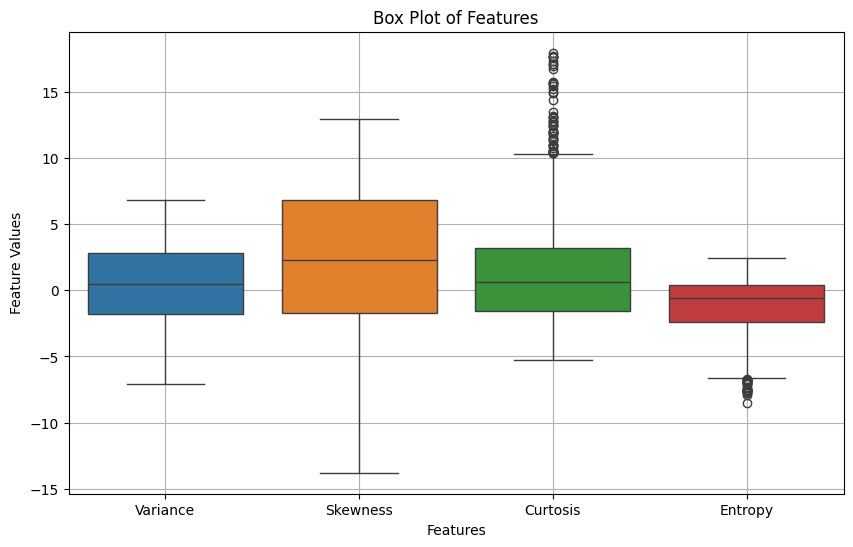

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df.iloc[:,:4])

plt.title("Box Plot of Features")

plt.xlabel("Features")

plt.ylabel("Feature Values")

plt.grid(True)

plt.show()

The boxplots show that most features have a reasonable spread with only a few outliers. Kurtosis contains several upper-end outliers, while the remaining features exhibit relatively stable distributions. Since these outliers represent genuine observations rather than data errors, they are retained for model training.

In [ ]:
#Normalize all numerical features.
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (1097, 4)
Testing Samples : (275, 4)


In [ ]:
class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=50):

        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

        self.errors = []
        self.weight_history = []
        self.bias_history = []

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, X):

        predictions = []

        for sample in X:
            linear_output = np.dot(sample, self.weights) + self.bias
            prediction = self.activation(linear_output)
            predictions.append(prediction)
        return np.array(predictions)

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        feature_names = [
            "Variance",
            "Skewness",
            "Kurtosis",
            "Entropy"
        ]

        print("MODEL TRAINING STARTED")
        print("-----")

        for epoch in range(self.epochs):

            errors = 0
            for sample, target in zip(X, y):
                linear_output = np.dot(sample, self.weights) + self.bias
                prediction = self.activation(linear_output)
                update = self.learning_rate * (target - prediction)
                self.weights += update * sample
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            print("-----")
            print(f"Epoch Number : {epoch+1}")
            print(f"Misclassified Samples : {errors}")
            print("\nUpdated Weights")

            for feature, weight in zip(feature_names, self.weights):
                print(f"{feature:<12}: {weight:.4f}")
            print(f"\nUpdated Bias : {self.bias:.4f}")

        print("\n" + "="*70)
        print("MODEL TRAINING COMPLETED")
        print("="*70)

In [ ]:


perceptron = Perceptron(
    learning_rate=0.01,
    epochs=50
)

perceptron.fit(X_train, y_train)

MODEL TRAINING STARTED
-----
-----
Epoch Number : 1
Misclassified Samples : 47

Updated Weights
Variance    : -0.0692
Skewness    : -0.0663
Kurtosis    : -0.0653
Entropy     : -0.0052

Updated Bias : -0.0300
-----
Epoch Number : 2
Misclassified Samples : 22

Updated Weights
Variance    : -0.0758
Skewness    : -0.0944
Kurtosis    : -0.0517
Entropy     : -0.0031

Updated Bias : -0.0300
-----
Epoch Number : 3
Misclassified Samples : 28

Updated Weights
Variance    : -0.0863
Skewness    : -0.1039
Kurtosis    : -0.0613
Entropy     : -0.0062

Updated Bias : -0.0300
-----
Epoch Number : 4
Misclassified Samples : 24

Updated Weights
Variance    : -0.0982
Skewness    : -0.0939
Kurtosis    : -0.0882
Entropy     : -0.0104

Updated Bias : -0.0500
-----
Epoch Number : 5
Misclassified Samples : 29

Updated Weights
Variance    : -0.1098
Skewness    : -0.1210
Kurtosis    : -0.0862
Entropy     : 0.0003

Updated Bias : -0.0400
-----
Epoch Number : 6
Misclassified Samples : 17

Updated Weights
Variance  

In [ ]:
# Predict the class labels for test data

y_pred = perceptron.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

In [ ]:

print("PERFORMANCE METRICS")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

PERFORMANCE METRICS
Accuracy  : 0.9818
Precision : 1.0000
Recall    : 0.9606
F1-Score  : 0.9799


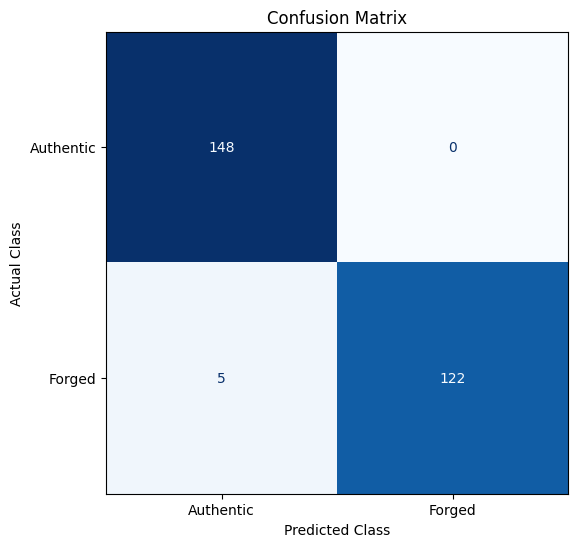

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Authentic", "Forged"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.grid(False)
plt.show()

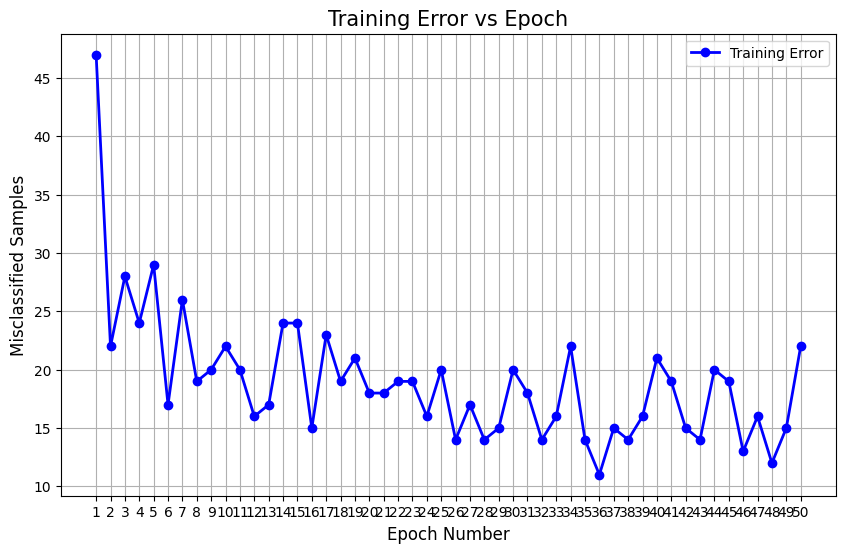

In [ ]:
plt.figure(figsize=(10,6))

epochs = range(1, len(perceptron.errors) + 1)

plt.plot(
    epochs,
    perceptron.errors,
    marker='o',
    linewidth=2,
    color='blue',
    label='Training Error'
)

plt.title("Training Error vs Epoch", fontsize=15)

plt.xlabel("Epoch Number", fontsize=12)

plt.ylabel("Misclassified Samples", fontsize=12)

plt.xticks(epochs)

plt.grid(True)

plt.legend()

plt.show()

The graph illustrates the variation in the number of misclassified samples across training epochs. Although minor fluctuations are observed, the overall error remains relatively low, indicating that the perceptron is learning the underlying decision boundary. The fluctuations occur because weights are updated after each individual training sample.

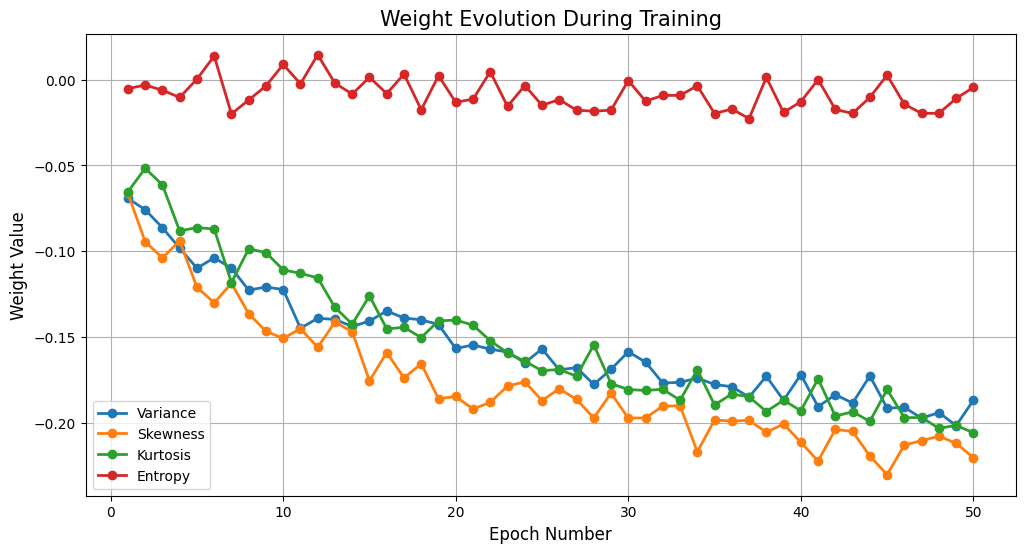

In [ ]:
weights = np.array(perceptron.weight_history)
epochs = range(1, len(weights)+1)
plt.figure(figsize=(12,6))
feature_names = [
    "Variance",
    "Skewness",
    "Kurtosis",
    "Entropy"
]

for i in range(weights.shape[1]):

    plt.plot(
        epochs,
        weights[:,i],
        marker='o',
        linewidth=2,
        label=feature_names[i]
    )

plt.title("Weight Evolution During Training", fontsize=15)
plt.xlabel("Epoch Number", fontsize=12)
plt.ylabel("Weight Value", fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

The graph shows how the weights associated with each feature evolve throughout the training process. Initially, the weights change rapidly as the perceptron learns from the training data. Towards later epochs, the changes become smaller, indicating that the model is approaching convergence and the learned feature importance is stabilizing.

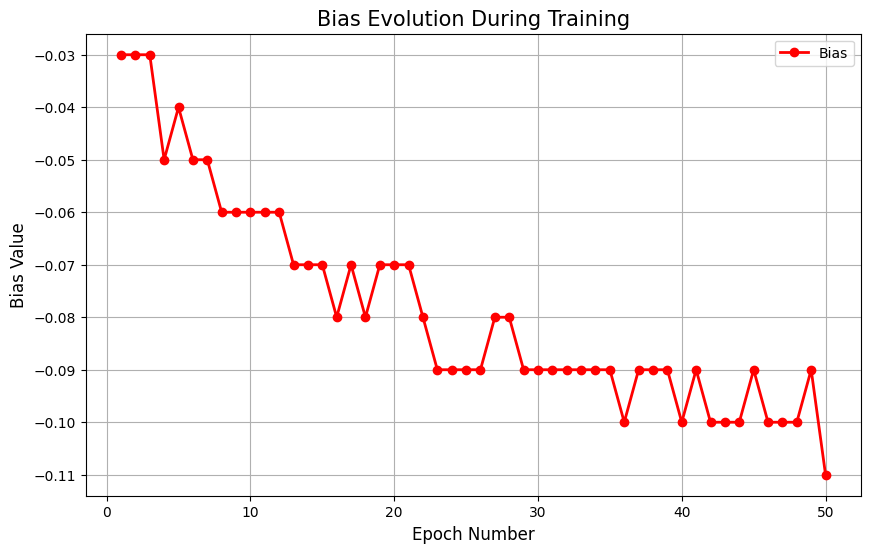

In [ ]:
epochs = range(1, len(perceptron.bias_history)+1)
plt.figure(figsize=(10,6))
plt.plot(
    epochs,
    perceptron.bias_history,
    marker='o',
    linewidth=2,
    color='red',
    label='Bias'
)

plt.title("Bias Evolution During Training", fontsize=15)
plt.xlabel("Epoch Number", fontsize=12)
plt.ylabel("Bias Value", fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

The bias changes during training to adjust the position of the decision boundary independently of the feature weights. As training progresses, the bias exhibits smaller changes, suggesting that the decision boundary is gradually stabilizing.

MODEL TRAINING STARTED
-----
-----
Epoch Number : 1
Misclassified Samples : 47

Updated Weights
Variance    : -0.0069
Skewness    : -0.0066
Kurtosis    : -0.0065
Entropy     : -0.0005

Updated Bias : -0.0030
-----
Epoch Number : 2
Misclassified Samples : 22

Updated Weights
Variance    : -0.0076
Skewness    : -0.0094
Kurtosis    : -0.0052
Entropy     : -0.0003

Updated Bias : -0.0030
-----
Epoch Number : 3
Misclassified Samples : 28

Updated Weights
Variance    : -0.0086
Skewness    : -0.0104
Kurtosis    : -0.0061
Entropy     : -0.0006

Updated Bias : -0.0030
-----
Epoch Number : 4
Misclassified Samples : 24

Updated Weights
Variance    : -0.0098
Skewness    : -0.0094
Kurtosis    : -0.0088
Entropy     : -0.0010

Updated Bias : -0.0050
-----
Epoch Number : 5
Misclassified Samples : 29

Updated Weights
Variance    : -0.0110
Skewness    : -0.0121
Kurtosis    : -0.0086
Entropy     : 0.0000

Updated Bias : -0.0040
-----
Epoch Number : 6
Misclassified Samples : 17

Updated Weights
Variance  

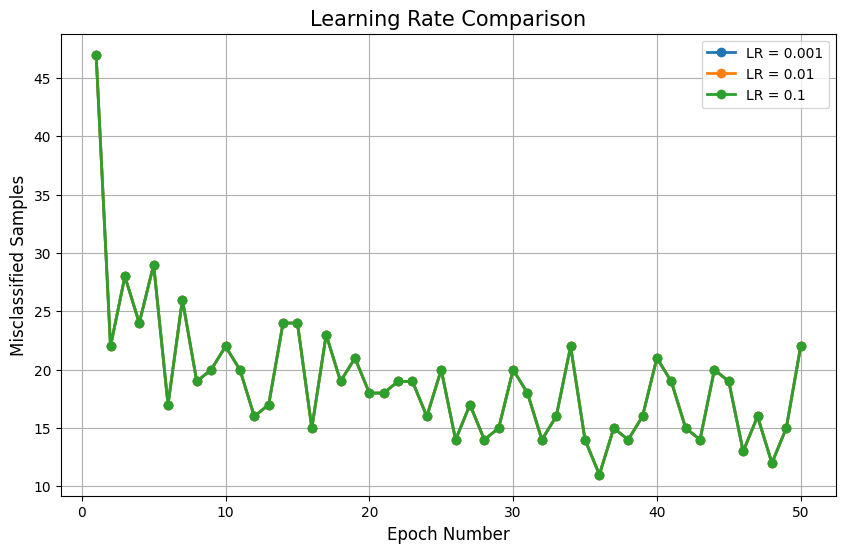

In [ ]:
learning_rates = [0.001, 0.01, 0.1]
plt.figure(figsize=(10,6))

for lr in learning_rates:

    model = Perceptron(
        learning_rate=lr,
        epochs=50
    )

    model.fit(X_train, y_train)

    epochs = range(1, len(model.errors)+1)

    plt.plot(
        epochs,
        model.errors,
        marker='o',
        linewidth=2,
        label=f"LR = {lr}"
    )
plt.title("Learning Rate Comparison", fontsize=15)
plt.xlabel("Epoch Number", fontsize=12)
plt.ylabel("Misclassified Samples", fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

The learning rate controls the magnitude of weight updates during training. Smaller learning rates generally lead to slower but more stable learning, whereas larger learning rates produce faster updates but may cause fluctuations or instability. A learning rate of 0.01 provides a good balance between convergence speed and stability for this dataset.

MODEL TRAINING STARTED
-----
-----
Epoch Number : 1
Misclassified Samples : 181

Updated Weights
Variance    : -0.0291
Skewness    : -0.0018

Updated Bias : 0.0100
-----
Epoch Number : 2
Misclassified Samples : 176

Updated Weights
Variance    : -0.0188
Skewness    : -0.0092

Updated Bias : 0.0100
-----
Epoch Number : 3
Misclassified Samples : 180

Updated Weights
Variance    : -0.0259
Skewness    : -0.0118

Updated Bias : 0.0100
-----
Epoch Number : 4
Misclassified Samples : 170

Updated Weights
Variance    : -0.0255
Skewness    : -0.0060

Updated Bias : 0.0100
-----
Epoch Number : 5
Misclassified Samples : 178

Updated Weights
Variance    : -0.0249
Skewness    : 0.0010

Updated Bias : 0.0100
-----
Epoch Number : 6
Misclassified Samples : 184

Updated Weights
Variance    : -0.0190
Skewness    : -0.0092

Updated Bias : 0.0100
-----
Epoch Number : 7
Misclassified Samples : 180

Updated Weights
Variance    : -0.0227
Skewness    : -0.0091

Updated Bias : 0.0100
-----
Epoch Number : 8
Misc

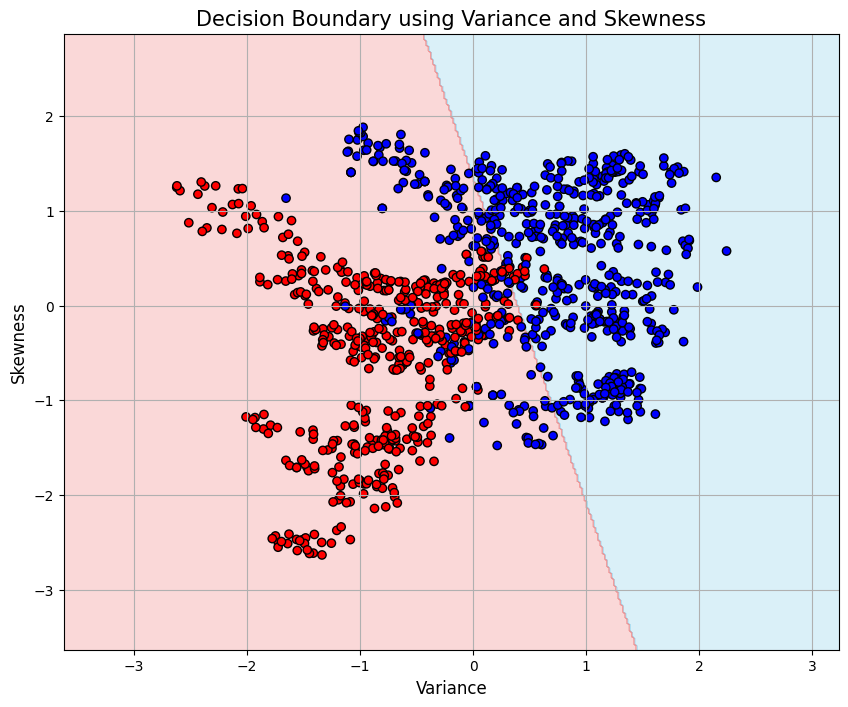

In [ ]:
from matplotlib.colors import ListedColormap

X_plot = X_train[:, :2]
y_plot = y_train.values

model = Perceptron(
    learning_rate=0.01,
    epochs=50
)

model.fit(X_plot, y_plot)

x1_min, x1_max = X_plot[:,0].min()-1, X_plot[:,0].max()+1
x2_min, x2_max = X_plot[:,1].min()-1, X_plot[:,1].max()+1

xx1, xx2 = np.meshgrid(
    np.arange(x1_min, x1_max, 0.02),
    np.arange(x2_min, x2_max, 0.02)
)

grid = np.array([xx1.ravel(), xx2.ravel()]).T
predictions = model.predict(grid)
predictions = predictions.reshape(xx1.shape)
plt.figure(figsize=(10,8))

plt.contourf(
    xx1,
    xx2,
    predictions,
    alpha=0.3,
    cmap=ListedColormap(("skyblue","lightcoral"))
)

plt.scatter(
    X_plot[:,0],
    X_plot[:,1],
    c=y_plot,
    edgecolor='k',
    cmap=ListedColormap(("blue","red"))
)
plt.title("Decision Boundary using Variance and Skewness", fontsize=15)
plt.xlabel("Variance", fontsize=12)
plt.ylabel("Skewness", fontsize=12)
plt.grid(True)
plt.show()

The decision boundary illustrates how the perceptron separates authentic and forged banknotes using the selected two features. Most samples lie on the correct side of the boundary, indicating that the dataset is approximately linearly separable. A small overlap between classes explains the remaining classification errors.

TRAINING PERCEPTRON FOR: AND GATE
Initial Weights : [0. 0.]   Initial Bias : 0.0000

Update  1  | Epoch  1, Sample [0 0] (target=0, predicted=1)
          -> Weights : [0. 0.]   Bias : -0.1000
Update  2  | Epoch  1, Sample [1 1] (target=1, predicted=0)
          -> Weights : [0.1 0.1]   Bias : 0.0000
Update  3  | Epoch  2, Sample [0 0] (target=0, predicted=1)
          -> Weights : [0.1 0.1]   Bias : -0.1000
Update  4  | Epoch  2, Sample [0 1] (target=0, predicted=1)
          -> Weights : [0.1 0. ]   Bias : -0.2000
Update  5  | Epoch  2, Sample [1 1] (target=1, predicted=0)
          -> Weights : [0.2 0.1]   Bias : -0.1000
Update  6  | Epoch  3, Sample [0 1] (target=0, predicted=1)
          -> Weights : [0.2 0. ]   Bias : -0.2000
Update  7  | Epoch  3, Sample [1 0] (target=0, predicted=1)
          -> Weights : [0.1 0. ]   Bias : -0.3000
Update  8  | Epoch  3, Sample [1 1] (target=1, predicted=0)
          -> Weights : [0.2 0.1]   Bias : -0.2000

Converged after epoch 4 (no misclassi

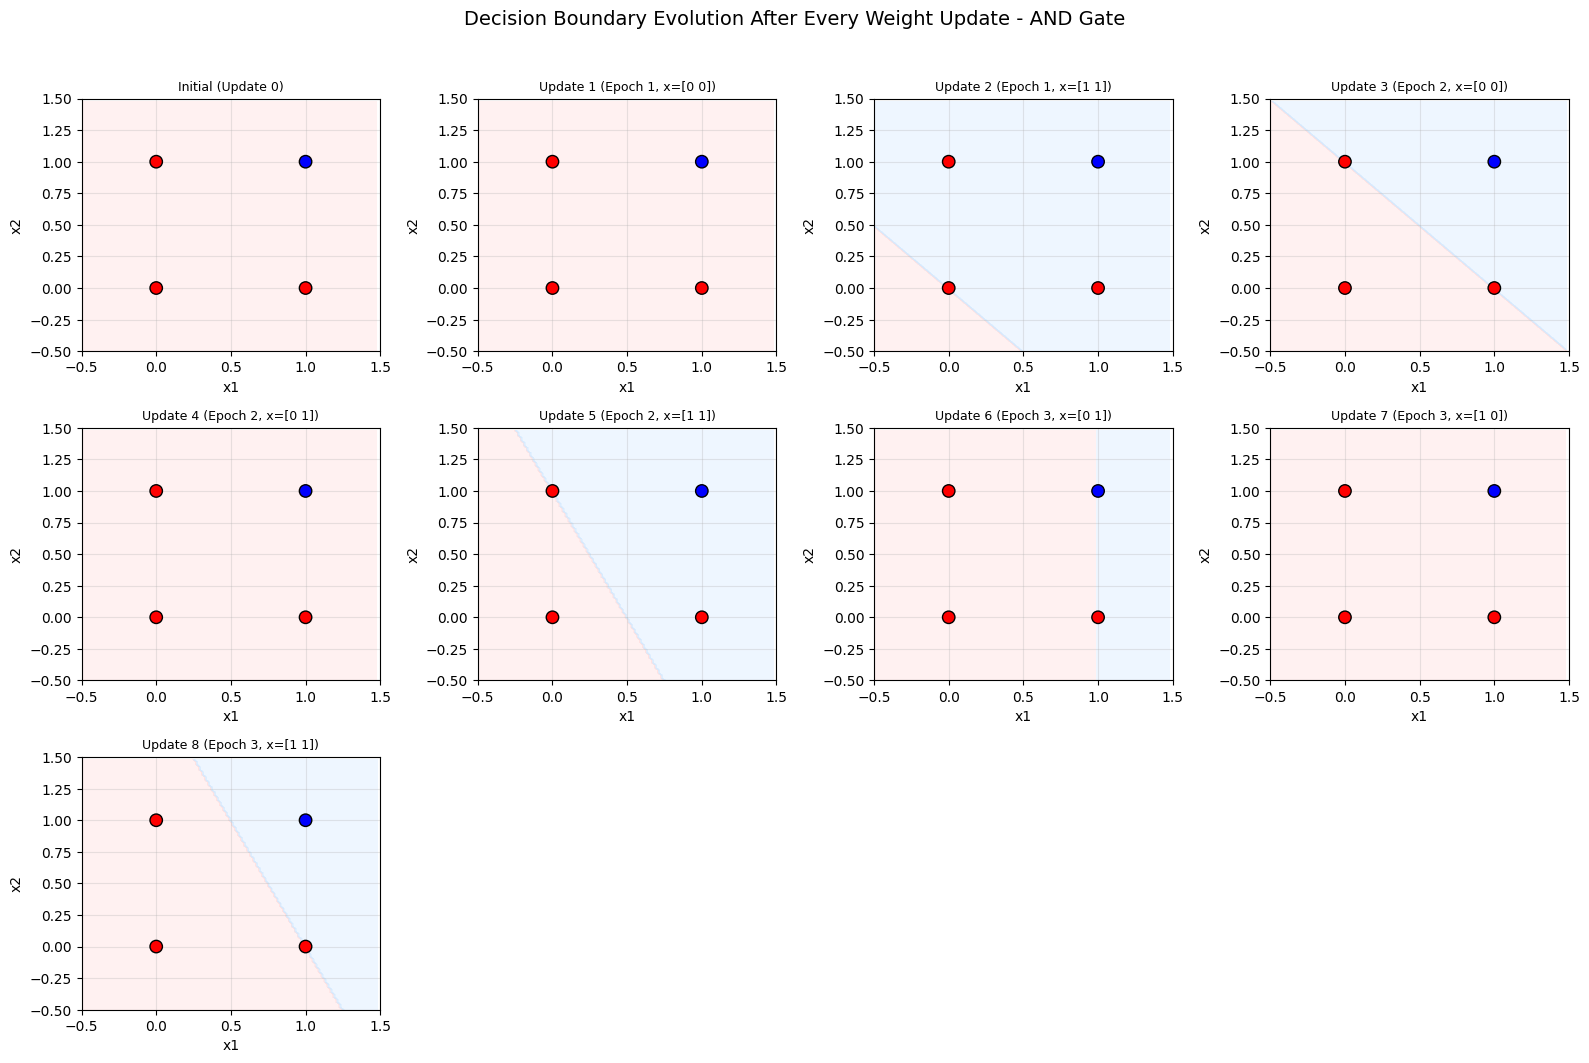

TRAINING PERCEPTRON FOR: OR GATE
Initial Weights : [0. 0.]   Initial Bias : 0.0000

Update  1  | Epoch  1, Sample [0 0] (target=0, predicted=1)
          -> Weights : [0. 0.]   Bias : -0.1000
Update  2  | Epoch  1, Sample [0 1] (target=1, predicted=0)
          -> Weights : [0.  0.1]   Bias : 0.0000
Update  3  | Epoch  2, Sample [0 0] (target=0, predicted=1)
          -> Weights : [0.  0.1]   Bias : -0.1000
Update  4  | Epoch  2, Sample [1 0] (target=1, predicted=0)
          -> Weights : [0.1 0.1]   Bias : 0.0000
Update  5  | Epoch  3, Sample [0 0] (target=0, predicted=1)
          -> Weights : [0.1 0.1]   Bias : -0.1000

Converged after epoch 4 (no misclassifications).
FINAL Weights : [0.1 0.1]   FINAL Bias : -0.1000



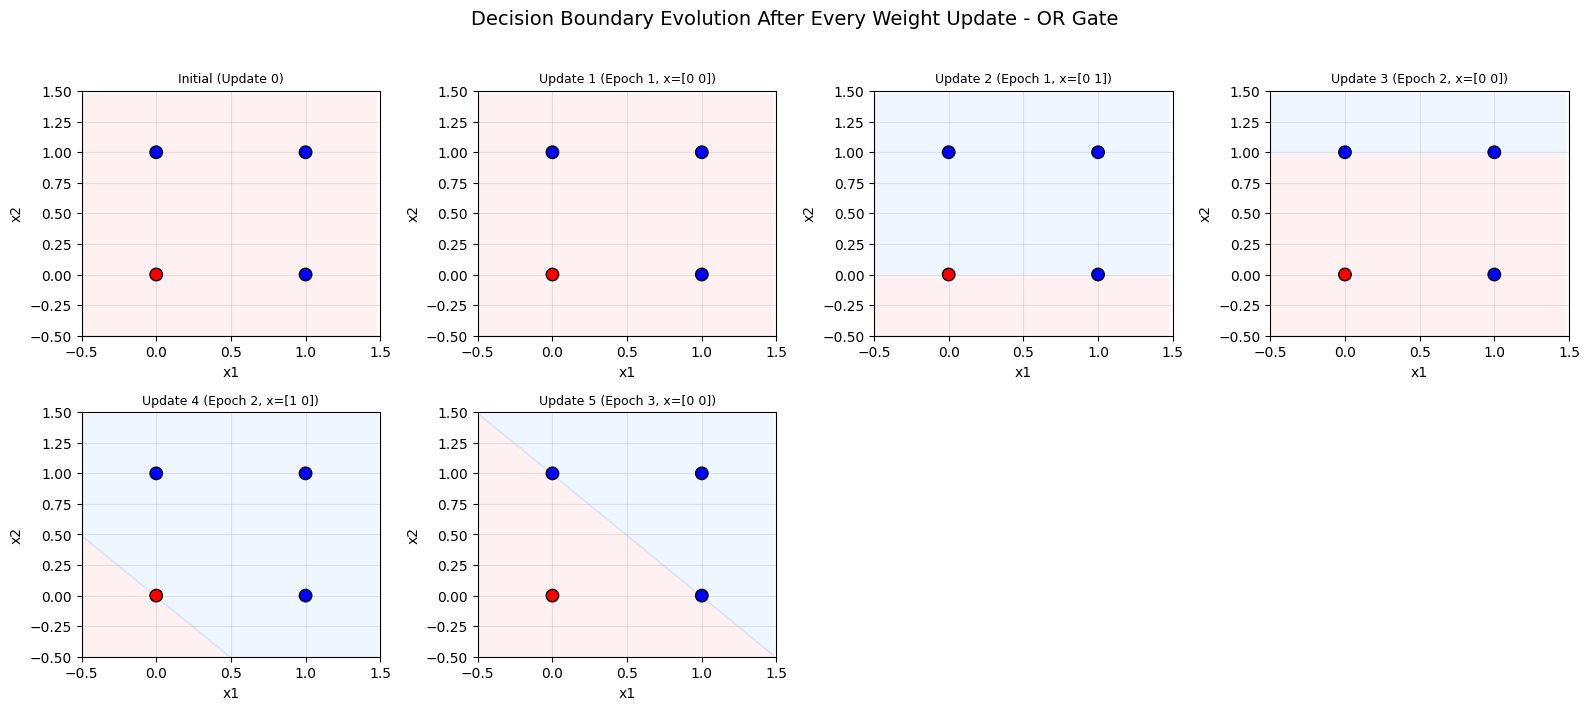

TRAINING PERCEPTRON FOR: NOT GATE
Initial Weights : [0.]   Initial Bias : 0.0000

Update  1  | Epoch  1, Sample [1] (target=0, predicted=1)
          -> Weights : [-0.1]   Bias : -0.1000
Update  2  | Epoch  2, Sample [0] (target=1, predicted=0)
          -> Weights : [-0.1]   Bias : 0.0000

Converged after epoch 3 (no misclassifications).
FINAL Weights : [-0.1]   FINAL Bias : 0.0000



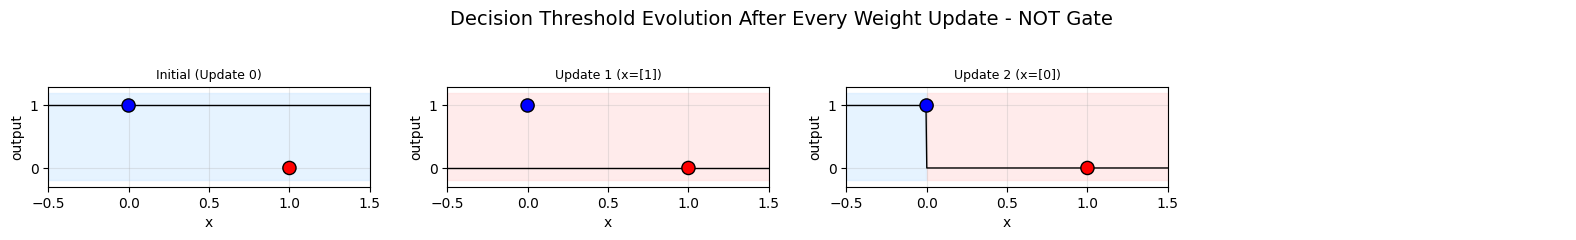

AND Gate -> Inputs:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
True: [0 0 0 1]  Predicted: [0 0 0 1]
All correct: True

OR Gate -> Inputs:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
True: [0 1 1 1]  Predicted: [0 1 1 1]
All correct: True

NOT Gate -> Inputs:
[[0]
 [1]]
True: [1 0]  Predicted: [1 0]
All correct: True



In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

np.set_printoptions(precision=4, suppress=True)

class LogicGatePerceptron:
    def __init__(self, learning_rate=0.1, epochs=20):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.history = []
    def activation(self, z):
        return 1 if z >= 0 else 0

    def predict_one(self, x):
        z = np.dot(x, self.weights) + self.bias
        return self.activation(z)

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])

    def fit(self, X, y, gate_name=""):
        n_features = X.shape[1]
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        update_no = 0

        self.history.append({
            "update": update_no, "epoch": 0, "sample": None,
            "x": None, "target": None, "pred": None,
            "weights": self.weights.copy(), "bias": self.bias
        })

        print("=" * 70)
        print(f"TRAINING PERCEPTRON FOR: {gate_name} GATE")
        print("=" * 70)
        print(f"Initial Weights : {self.weights}   Initial Bias : {self.bias:.4f}\n")

        for epoch in range(1, self.epochs + 1):
            errors = 0
            for i, (xi, target) in enumerate(zip(X, y)):
                z = np.dot(xi, self.weights) + self.bias
                pred = self.activation(z)
                error = target - pred
                update = self.learning_rate * error

                if update != 0:
                    self.weights = self.weights + update * xi
                    self.bias = self.bias + update
                    update_no += 1
                    errors += 1

                    self.history.append({
                        "update": update_no, "epoch": epoch, "sample": i,
                        "x": xi.copy(), "target": target, "pred": pred,
                        "weights": self.weights.copy(), "bias": self.bias
                    })

                    print(f"Update {update_no:2d}  | Epoch {epoch:2d}, Sample {xi} "
                          f"(target={target}, predicted={pred})")
                    print(f"          -> Weights : {self.weights}   Bias : {self.bias:.4f}")

            if errors == 0:
                print(f"\nConverged after epoch {epoch} (no misclassifications).")
                break

        print("=" * 70)
        print(f"FINAL Weights : {self.weights}   FINAL Bias : {self.bias:.4f}")
        print("=" * 70 + "\n")
        return self
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

X_not = np.array([[0], [1]])
y_not = np.array([1, 0])

def plot_boundary_evolution_2d(history, X, y, gate_name, filename):
    n_plots = len(history)
    n_cols = 4
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.6 * n_rows))
    axes = np.array(axes).reshape(-1)

    x1_min, x1_max = -0.5, 1.5
    x2_min, x2_max = -0.5, 1.5
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.02),
                            np.arange(x2_min, x2_max, 0.02))

    cmap_bg = ListedColormap(["#ffd9d9", "#cfe8ff"])
    cmap_pts = ListedColormap(["red", "blue"])

    for idx, record in enumerate(history):
        ax = axes[idx]
        w, b = record["weights"], record["bias"]

        grid = np.c_[xx1.ravel(), xx2.ravel()]
        z = (np.dot(grid, w) + b >= 0).astype(int).reshape(xx1.shape)

        ax.contourf(xx1, xx2, z, alpha=0.35, cmap=cmap_bg)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_pts, edgecolor="k", s=80, zorder=3)

        if record["update"] == 0:
            title = "Initial (Update 0)"
        else:
            title = f"Update {record['update']} (Epoch {record['epoch']}, x={record['x']})"
        ax.set_title(title, fontsize=9)
        ax.set_xlim(x1_min, x1_max)
        ax.set_ylim(x2_min, x2_max)
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.grid(alpha=0.3)

    for j in range(n_plots, len(axes)):
        axes[j].axis("off")
    fig.suptitle(f"Decision Boundary Evolution After Every Weight Update - {gate_name} Gate",
                  fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    plt.show()
    plt.close(fig)


def plot_boundary_evolution_1d(history, X, y, filename):
    n_plots = len(history)
    n_cols = 4
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 2.4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for idx, record in enumerate(history):
        ax = axes[idx]
        w, b = record["weights"][0], record["bias"]

        xs = np.linspace(-0.5, 1.5, 400)
        preds = (w * xs + b >= 0).astype(int)

        ax.plot(xs, preds, color="black", lw=1)
        ax.fill_between(xs, -0.2, 1.2, where=(w * xs + b >= 0),
                         color="#cfe8ff", alpha=0.5)
        ax.fill_between(xs, -0.2, 1.2, where=(w * xs + b < 0),
                         color="#ffd9d9", alpha=0.5)

        ax.scatter(X[:, 0], y, c=y, cmap=ListedColormap(["red", "blue"]),
                    edgecolor="k", s=90, zorder=3)

        if record["update"] == 0:
            title = "Initial (Update 0)"
        else:
            title = f"Update {record['update']} (x={record['x']})"
        ax.set_title(title, fontsize=9)
        ax.set_ylim(-0.3, 1.3)
        ax.set_xlim(-0.5, 1.5)
        ax.set_xlabel("x")
        ax.set_ylabel("output")
        ax.grid(alpha=0.3)

    for j in range(n_plots, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Decision Threshold Evolution After Every Weight Update - NOT Gate",
                fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.94])

    plt.show()
    plt.close(fig)

if __name__ == "__main__":
    # ---- AND gate ----
    and_model = LogicGatePerceptron(learning_rate=0.1, epochs=20)
    and_model.fit(X_and, y_and, gate_name="AND")
    plot_boundary_evolution_2d(and_model.history, X_and, y_and, "AND", None)

    # ---- OR gate ----
    or_model = LogicGatePerceptron(learning_rate=0.1, epochs=20)
    or_model.fit(X_or, y_or, gate_name="OR")
    plot_boundary_evolution_2d(or_model.history, X_or, y_or, "OR", None)

    # ---- NOT gate ----
    not_model = LogicGatePerceptron(learning_rate=0.1, epochs=20)
    not_model.fit(X_not, y_not, gate_name="NOT")
    plot_boundary_evolution_1d(not_model.history, X_not, y_not, None)

    # ---- Final predictions / verification ----
    for name, model, X, y in [("AND", and_model, X_and, y_and),
                               ("OR", or_model, X_or, y_or),
                               ("NOT", not_model, X_not, y_not)]:
        preds = model.predict(X)
        print(f"{name} Gate -> Inputs:\n{X}\nTrue: {y}  Predicted: {preds}")
        print(f"All correct: {np.array_equal(preds, y)}\n")